In [9]:
#setup
## Install required packages
!pip install -q moabb mne scikit-learn matplotlib pandas numpy joblib

# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from mne import set_config

from moabb.datasets import BNCI2014_001
from moabb.paradigms import LeftRightImagery
from moabb.evaluations import WithinSessionEvaluation

from sklearn.pipeline import make_pipeline
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.svm import SVC

print("Setup complete.")

Setup complete.


In [10]:
#Configure folders and load dataset
mne_data_path = "/Users/hosseinmoeinzadeh/mne_data"
results_path = "results"

os.makedirs(mne_data_path, exist_ok=True)
os.makedirs(results_path, exist_ok=True)

set_config("MNE_DATA", mne_data_path)

dataset = BNCI2014_001()

# Use one subject for a clean and fast portfolio project
dataset.subject_list = [1]

paradigm = LeftRightImagery()

print("Dataset loaded successfully.")
print("Dataset:", dataset.code)
print("Subjects used:", dataset.subject_list)
print("Task: left-hand vs right-hand motor imagery classification")

Dataset loaded successfully.
Dataset: BNCI2014-001
Subjects used: [1]
Task: left-hand vs right-hand motor imagery classification


In [11]:
# Build BCI pipelines
pipeline_lda = make_pipeline(
    CSP(n_components=6, log=True, norm_trace=False),
    LDA()
)

pipeline_svm = make_pipeline(
    CSP(n_components=6, log=True, norm_trace=False),
    SVC(kernel="linear", probability=True)
)

pipelines = {
    "CSP + LDA": pipeline_lda,
    "CSP + SVM": pipeline_svm
}

print("BCI pipelines created successfully.")

BCI pipelines created successfully.


In [12]:
# Run evaluation

evaluation = WithinSessionEvaluation(
    paradigm=paradigm,
    datasets=[dataset],
    overwrite=True,
    suffix="lda_svm_comparison",
    error_score="raise"
)

results = evaluation.process(pipelines)

display(results)

print("Pipelines in results:")
print(results["pipeline"].unique())

Computing rank from data with rank=None
    Using tolerance 33 (2.2e-16 eps * 22 dim * 6.7e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 33 (2.2e-16 eps * 22 dim * 6.7e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 33 (2.2e-16 eps * 22 dim * 6.7e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Es

,score,time,samples,samples_test,n_classes,subject,session,channels,n_sessions,dataset,pipeline
0,0.950204,0.125354,144.0,28.0,2.0,1,0train,22,2,BNCI2014-001,CSP + SVM
1,0.963673,0.109104,144.0,28.0,2.0,1,1test,22,2,BNCI2014-001,CSP + SVM
2,0.939728,0.122319,144.0,28.0,2.0,1,0train,22,2,BNCI2014-001,CSP + LDA
3,0.946327,0.107166,144.0,28.0,2.0,1,1test,22,2,BNCI2014-001,CSP + LDA


Pipelines in results:
['CSP + SVM' 'CSP + LDA']


,score,time,samples,samples_test,n_classes,subject,session,channels,n_sessions,dataset,pipeline
0,0.950204,0.125354,144.0,28.0,2.0,1,0train,22,2,BNCI2014-001,CSP + SVM
1,0.963673,0.109104,144.0,28.0,2.0,1,1test,22,2,BNCI2014-001,CSP + SVM
2,0.939728,0.122319,144.0,28.0,2.0,1,0train,22,2,BNCI2014-001,CSP + LDA
3,0.946327,0.107166,144.0,28.0,2.0,1,1test,22,2,BNCI2014-001,CSP + LDA


,mean,std
pipeline,,
CSP + LDA,0.943027,0.004666
CSP + SVM,0.956939,0.009524


Performance summary:
               mean       std
pipeline                     
CSP + LDA  0.943027  0.004666
CSP + SVM  0.956939  0.009524


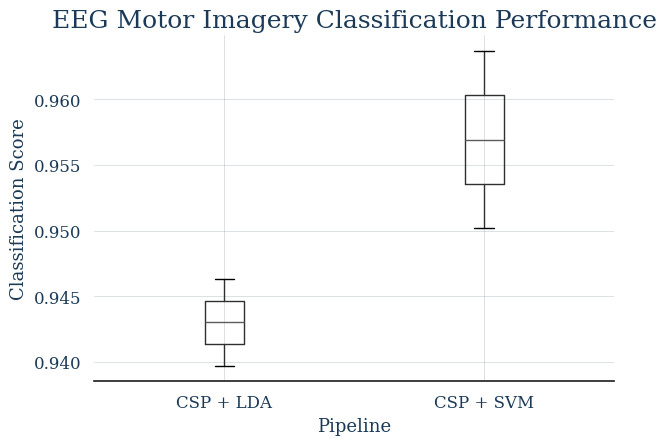

Results saved:
- results/eeg_motor_imagery_results.csv
- results/eeg_pipeline_summary.csv
- results/eeg_pipeline_comparison.png


In [13]:
# Results, saving, and visualization

results_df = results.copy()

display(results_df)

summary_df = results_df.groupby("pipeline")["score"].agg(["mean", "std"])

display(summary_df)

print("Performance summary:")
print(summary_df)

# Save results tables
results_df.to_csv(
    "results/eeg_motor_imagery_results.csv",
    index=False
)

summary_df.to_csv(
    "results/eeg_pipeline_summary.csv"
)

# Plot comparison
results_df.boxplot(column="score", by="pipeline")

plt.title("EEG Motor Imagery Classification Performance")
plt.suptitle("")

plt.ylabel("Classification Score")
plt.xlabel("Pipeline")

plt.tight_layout()

plt.savefig(
    "results/eeg_pipeline_comparison.png",
    dpi=300
)

plt.show()

print("Results saved:")
print("- results/eeg_motor_imagery_results.csv")
print("- results/eeg_pipeline_summary.csv")
print("- results/eeg_pipeline_comparison.png")